In [1]:
import pandas as pd

In [2]:
data = pd.read_parquet('../data/gold/session_laps_Y2026.parquet')

In [3]:
data.head().T

,0,1,2,3,4
year,2026,2026,2026,2026,2026
session_id,Y2026R01S1,Y2026R01S1,Y2026R01S1,Y2026R01S1,Y2026R01S1
driver_number,1,1,1,1,1
driver_name,NOR,NOR,NOR,NOR,NOR
driver_team,McLaren,McLaren,McLaren,McLaren,McLaren
lap_number,1,2,3,4,5
stint,1.0,1.0,2.0,3.0,3.0
timestamp_lap_start,2026-03-06 01:31:54.088000+00:00,2026-03-06 01:34:11.221000+00:00,2026-03-06 01:44:43.021000+00:00,2026-03-06 01:51:45.122000+00:00,2026-03-06 01:53:26.533000+00:00
timing_start_lap,1014.076,1151.209,1783.009,2205.11,2306.521
timing_end_lap,1151.209,1783.009,2205.11,2306.521,2391.427


In [4]:
def fetch_events(df_):
    primary_key = ['session_id', 'driver_number']
    events = []
    for _, lap in df_.iterrows():
        if pd.notna(lap['timing_pit_out']):
            events.append({
                **{c: lap[c] for c in primary_key},
                'timestamp': lap['timing_pit_out'],
                'event': 'pit_out',
            })
        else:
            events.append({
                **{c: lap[c] for c in primary_key},
                'timestamp': lap['timing_start_lap'],
                'event': 'start_lap',
            })
        if pd.notna(lap['timing_pit_in']):
            events.append({
                **{c: lap[c] for c in primary_key},
                'timestamp': lap['timing_pit_in'],
                'event': 'pit_in',
            })
        else:
            events.append({
                **{c: lap[c] for c in primary_key},
                'timestamp': lap['timing_end_lap'],
                'event': 'end_lap',
            })
    return sorted(events, key=lambda x: x['timestamp'])


In [5]:
events = pd.DataFrame(fetch_events(data[data['session_id']=='Y2026R01S4']))

In [6]:
events[(events['driver_number']==1) & (events['event'].isin(['pit_out', 'pit_in']))]

,session_id,driver_number,timestamp,event
12,Y2026R01S4,1,853.070,pit_out
188,Y2026R01S4,1,1444.642,pit_in
194,Y2026R01S4,1,1907.118,pit_out
327,Y2026R01S4,1,2399.189,pit_in
347,Y2026R01S4,1,2832.151,pit_out
454,Y2026R01S4,1,3212.958,pit_in
474,Y2026R01S4,1,3382.266,pit_out
553,Y2026R01S4,1,3662.685,pit_in
591,Y2026R01S4,1,4386.557,pit_out
618,Y2026R01S4,1,4587.999,pit_in


In [7]:
events[(events['driver_number']==1)]

,session_id,driver_number,timestamp,event
12,Y2026R01S4,1,853.070,pit_out
45,Y2026R01S4,1,969.950,end_lap
46,Y2026R01S4,1,969.950,start_lap
74,Y2026R01S4,1,1051.182,end_lap
75,Y2026R01S4,1,1051.182,start_lap
112,Y2026R01S4,1,1160.906,end_lap
113,Y2026R01S4,1,1160.906,start_lap
141,Y2026R01S4,1,1258.390,end_lap
142,Y2026R01S4,1,1258.390,start_lap
169,Y2026R01S4,1,1338.838,end_lap


In [8]:
data[(data['session_id']=='Y2026R01S4') & (data['driver_number']==1)][[
    'timing_start_lap', 'timing_end_lap', 'timing_pit_out', 'timing_pit_in',
]]

,timing_start_lap,timing_end_lap,timing_pit_out,timing_pit_in
1408,853.070,969.950,853.070,NaN
1409,969.950,1051.182,NaN,NaN
1410,1051.182,1160.906,NaN,NaN
1411,1160.906,1258.390,NaN,NaN
1412,1258.390,1338.838,NaN,NaN
1413,1338.838,1907.118,NaN,1444.642
1414,1907.118,2005.536,1907.118,NaN
1415,2005.536,2100.590,NaN,NaN
1416,2100.590,2193.392,NaN,NaN
1417,2193.392,2273.402,NaN,NaN


In [9]:
positions = pd.read_parquet('../data/gold/telemetry_pos_Y2026R01.parquet')

In [10]:
positions[['session_id', 'driver_number', 'timing_from_session', 'coordinate_x', 'coordinate_y']]

,session_id,driver_number,timing_from_session,coordinate_x,coordinate_y
0,Y2026R01S1,1,1014.086,-1262.0,-1068.0
1,Y2026R01S1,1,1014.336,-1271.0,-1059.0
2,Y2026R01S1,1,1014.676,-1279.0,-1051.0
3,Y2026R01S1,1,1014.925,-1288.0,-1042.0
4,Y2026R01S1,1,1015.195,-1305.0,-1026.0
...,...,...,...,...,...
1393803,Y2026R01S5,87,8730.458,-597.0,-1902.0
1393804,Y2026R01S5,87,8730.638,-703.0,-1801.0
1393805,Y2026R01S5,87,8730.958,-756.0,-1751.0
1393806,Y2026R01S5,87,8731.018,-792.0,-1716.0


In [11]:
session_id = 'Y2026R01S4'
df_events = pd.DataFrame(fetch_events(data[data['session_id']==session_id]))
df_positions = positions[positions['session_id']==session_id]

In [12]:
from sklearn.neighbors import NearestNeighbors

In [13]:
xx = df_events[df_events['driver_number']==1]['timestamp'].values.reshape(-1, 1)
yy = df_positions[df_positions['driver_number']==1]['timing_from_session'].values.reshape(-1, 1)
nbrs = NearestNeighbors(n_neighbors=1).fit(yy).kneighbors(xx)

In [14]:
print(nbrs[0][0:5])
print(nbrs[1][0:5])
print([yy[i][0,0] for i in nbrs[1][0:5]])
print(xx[0:5])

[[0.191]
 [0.131]
 [0.131]
 [0.06 ]
 [0.06 ]]
[[  0]
 [454]
 [454]
 [754]
 [754]]
[np.float64(853.261), np.float64(970.081), np.float64(970.081), np.float64(1051.242), np.float64(1051.242)]
[[ 853.07 ]
 [ 969.95 ]
 [ 969.95 ]
 [1051.182]
 [1051.182]]


In [15]:
events

,session_id,driver_number,timestamp,event
0,Y2026R01S4,27,764.437,pit_out
1,Y2026R01S4,23,768.671,pit_out
2,Y2026R01S4,31,773.218,pit_out
3,Y2026R01S4,87,777.406,pit_out
4,Y2026R01S4,43,786.921,pit_out
...,...,...,...,...
701,Y2026R01S4,12,5575.374,pit_in
702,Y2026R01S4,41,5581.858,end_lap
703,Y2026R01S4,30,5591.212,end_lap
704,Y2026R01S4,63,5607.599,pit_in


In [16]:
round_ = "Y2026R01"
events = pd.DataFrame(fetch_events(data[data['session_id'].str.startswith(round_)]))
positions = pd.read_parquet(f'../data/gold/telemetry_pos_{round_}.parquet')
aux = []
cols = ['timing_from_session', 'coordinate_x', 'coordinate_y', 'coordinate_z', 'track_status', 'position_status']
for session_id in events['session_id'].unique():
    split11 = events[events['session_id']==session_id]
    split21 = positions[positions['session_id']==session_id]
    for driver in split11['driver_number'].unique():
        split12 = split11[split11['driver_number']==driver]
        split22 = split21[split21['driver_number']==driver]
        nbrs = NearestNeighbors(n_neighbors=1).fit(
            split22['timing_from_session'].values.reshape(-1, 1)
        ).kneighbors(
            split12['timestamp'].values.reshape(-1, 1)            
        )
        for col in cols:
            split12[col] = [split22[col].iloc[i] for i in nbrs[1].reshape(-1)]
        aux.append(split12)

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_44813/1603564648.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split12[col] = [split22[col].iloc[i] for i in nbrs[1].reshape(-1)]
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_44813/1603564648.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split12[col] = [split22[col].iloc[i] for i in nbrs[1].reshape(-1)]
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_44813/1603564648.py:18: SettingWithCopyWarning: 
A value is t

In [24]:
df = pd.concat(aux)
df

,session_id,driver_number,timestamp,event,timing_from_session,coordinate_x,coordinate_y,coordinate_z,track_status,position_status
0,Y2026R01S4,27,764.437,pit_out,764.481,-1327.0,-1005.0,0.0,1,OnTrack
27,Y2026R01S4,27,866.869,end_lap,867.002,-1274.0,-1259.0,84.0,1,OnTrack
28,Y2026R01S4,27,866.869,start_lap,867.002,-1274.0,-1259.0,84.0,1,OnTrack
92,Y2026R01S4,27,963.005,end_lap,963.121,-1278.0,-1255.0,84.0,1,OnTrack
93,Y2026R01S4,27,963.005,start_lap,963.121,-1278.0,-1255.0,84.0,1,OnTrack
...,...,...,...,...,...,...,...,...,...,...
5453,Y2026R01S5,87,8558.351,end_lap,8558.337,-1159.0,-1368.0,85.0,1,OnTrack
5454,Y2026R01S5,87,8558.351,start_lap,8558.337,-1159.0,-1368.0,85.0,1,OnTrack
5487,Y2026R01S5,87,8644.790,end_lap,8644.818,-1198.0,-1331.0,85.0,1,OnTrack
5488,Y2026R01S5,87,8644.790,start_lap,8644.818,-1198.0,-1331.0,85.0,1,OnTrack


In [25]:
df.groupby(['session_id']).agg({'driver_number': 'nunique'})

,driver_number
session_id,
Y2026R01S1,21
Y2026R01S2,22
Y2026R01S3,21
Y2026R01S4,20
Y2026R01S5,21


In [31]:
df[df['event']=='end_lap'][['timing_from_session', 'coordinate_x', 'coordinate_y']].describe()

,timing_from_session,coordinate_x,coordinate_y
count,2394.000000,2394.000000,2394.000000
mean,4302.696366,-1184.044695,-1338.686717
std,2091.510336,159.376211,140.209212
min,867.002000,-1559.000000,-4335.000000
25%,2705.099000,-1246.000000,-1382.000000
50%,4076.299500,-1194.000000,-1335.000000
75%,5678.436750,-1144.000000,-1285.000000
max,8807.857000,2813.000000,1345.000000


In [32]:
df[df['event']=='start_lap'][['timing_from_session', 'coordinate_x', 'coordinate_y']].describe()

,timing_from_session,coordinate_x,coordinate_y
count,2389.000000,2389.000000,2389.000000
mean,4262.531978,-1181.742152,-1343.629134
std,2058.904901,141.349788,134.008037
min,867.002000,-1559.000000,-3683.000000
25%,2702.275000,-1246.000000,-1382.000000
50%,4012.435000,-1194.000000,-1335.000000
75%,5607.157000,-1144.000000,-1285.000000
max,8721.957000,1446.000000,0.000000


In [33]:
df[df['event']=='pit_in'][['timing_from_session', 'coordinate_x', 'coordinate_y']].describe()

,timing_from_session,coordinate_x,coordinate_y
count,374.000000,374.000000,374.000000
mean,3540.822088,622.470588,-3000.893048
std,1430.318430,1267.759761,629.673075
min,1083.605000,-10222.000000,-6819.000000
25%,2434.258250,711.000000,-3000.000000
50%,3517.791000,725.000000,-2987.000000
75%,4652.056750,738.000000,-2973.000000
max,8437.477000,5919.000000,2616.000000


In [34]:
df[df['event']=='pit_out'][['timing_from_session', 'coordinate_x', 'coordinate_y']].describe()

,timing_from_session,coordinate_x,coordinate_y
count,379.000000,379.000000,379.000000
mean,3091.708934,-1382.989446,-1058.759894
std,1556.803604,795.449638,520.676064
min,764.481000,-10222.000000,-6819.000000
25%,1942.241500,-1345.500000,-1038.000000
50%,2960.105000,-1313.000000,-1019.000000
75%,4237.478500,-1293.000000,-988.000000
max,8460.238000,0.000000,0.000000


<Axes: ylabel='Frequency'>

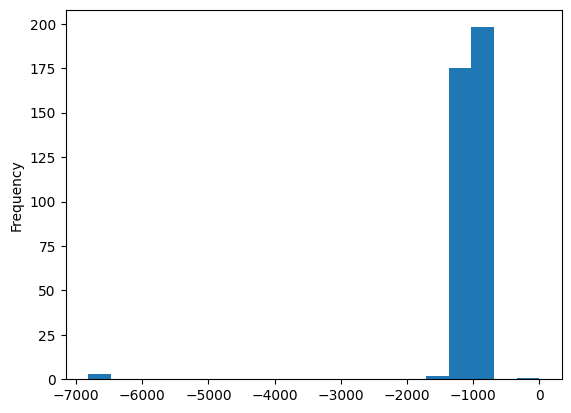

In [35]:
df[df['event']=='pit_out']['coordinate_y'].plot.hist(bins=20)

<Axes: ylabel='Frequency'>

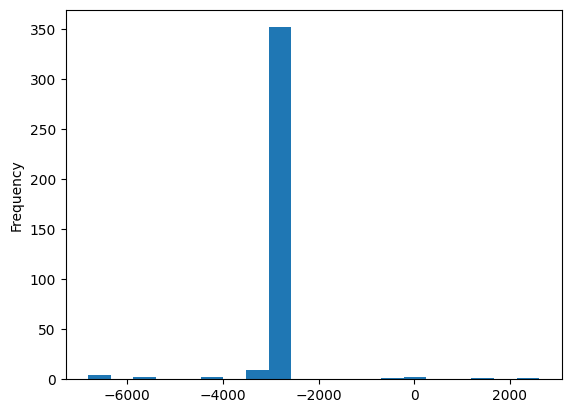

In [36]:
df[df['event']=='pit_in']['coordinate_y'].plot.hist(bins=20)

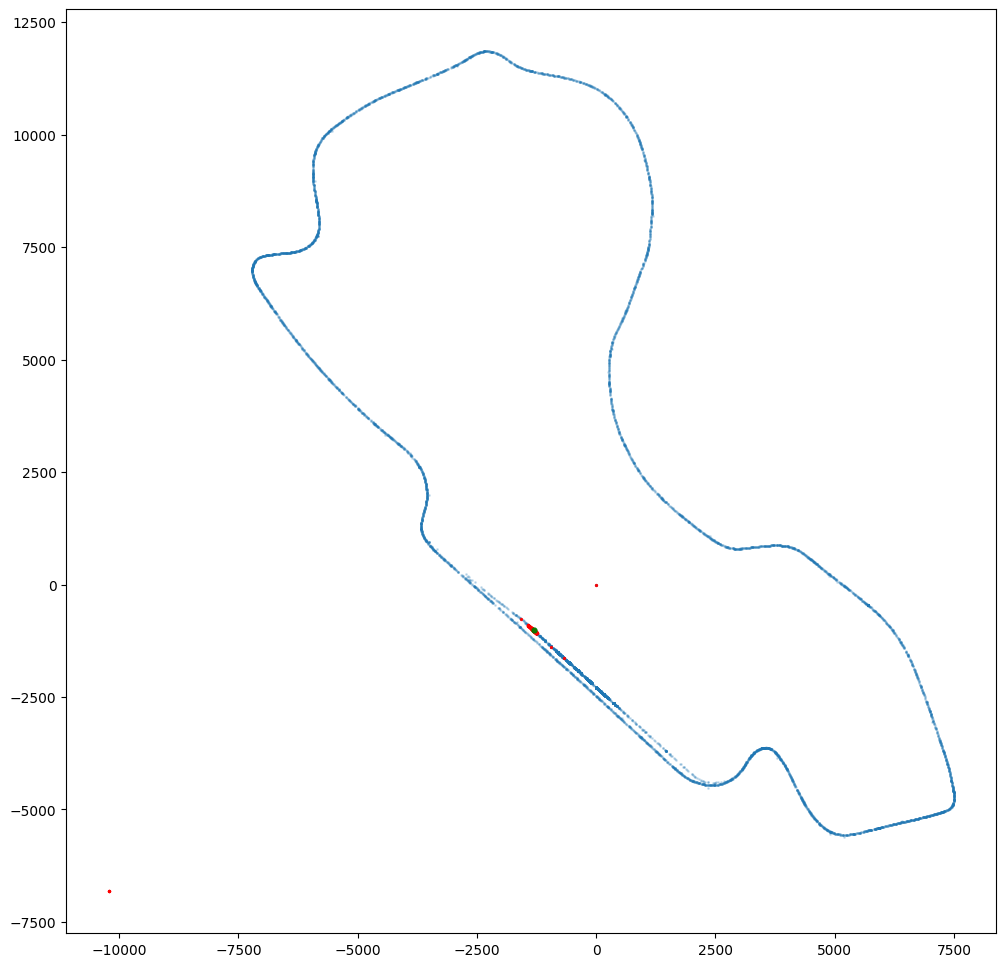

In [49]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 12))

plot_df = positions.sample(n=10000)
ax.scatter(plot_df['coordinate_x'], plot_df['coordinate_y'], s=1, alpha=0.2)

# plot_df = df[df['event']=='pit_in']
# ax.scatter(plot_df['coordinate_x'], plot_df['coordinate_y'], s=2, alpha=0.9, color='red')

# plot_df = df[df['event']=='pit_in'][['coordinate_x', 'coordinate_y']].median()
# ax.scatter(plot_df['coordinate_x'], plot_df['coordinate_y'], s=12, alpha=0.9, color='green')

plot_df = df[df['event']=='pit_out']
ax.scatter(plot_df['coordinate_x'], plot_df['coordinate_y'], s=2, alpha=0.9, color='red')

plot_df = df[df['event']=='pit_out'][['coordinate_x', 'coordinate_y']].median()
ax.scatter(plot_df['coordinate_x'], plot_df['coordinate_y'], s=12, alpha=0.9, color='green')


In [43]:
plot_df[['coordinate_x', 'coordinate_y']].median()

coordinate_x     725.0
coordinate_y   -2987.0
dtype: float64